# Linear regression, part 2: checking the fit

Part 1 produced a fitted model. A model that fits is not automatically a model to trust, so here we check it:

1. residuals and standardized residuals
2. the four assumptions behind linear regression, each on data that satisfies it and data that breaks it
3. correlated features: when coefficients stop being interpretable
4. hidden groups in the data: Simpson's paradox

In [ ]:
# setup: the same data and fitted model as in part 1, so this notebook runs on its own
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

data = {
    'Quizzes': [5.3, 5.5, 5.5, 5.0, 2.5, 3.0, 3.0, 3.1, 3.5, 3.5, 3.7, 4.0, 4.0, 4.0, 4.0, 5.7],
    'Labs':    [5.3, 5.9, 5.29, 4.35, 5.5, 5.0, 4.0, 3.1, 4.5, 5.62, 5.0, 3.0, 4.0, 5.75, 4.44, 5.9],
    'Final':   [4.818, 5.773, 4.464, 5.069, 4.164, 4.091, 3.727, 3.909,
                3.518, 4.897, 5.209, 3.0, 3.091, 5.818, 4.069, 5.77]
}
df = pd.DataFrame(data)

# the same augmentation as in part 1: 10 noisy copies of every student
np.random.seed(42)
augmented = []
for i in range(len(df)):
    row = df.iloc[i]
    for _ in range(10):
        augmented.append((row + np.random.normal(0, 0.2, 3)).clip(2, 6))
df_aug = pd.DataFrame(augmented, columns=df.columns)
print(f"{len(df_aug)} samples")

**Standardized residuals**

In [ ]:
# Data (univariate again)
data = {
    'Quizzes': [5.3, 5.5, 5.5, 5.0, 2.5, 3.0, 3.0, 3.1, 3.5, 3.5, 3.7, 4.0, 4.0, 4.0, 4.0, 5.7],
    'Labs': [5.3, 5.9, 5.29, 4.35, 5.5, 5.0, 4.0, 3.1, 4.5, 5.62, 5.0, 3.0, 4.0, 5.75, 4.44, 5.9],
    'Final': [4.818, 5.773, 4.464, 5.069, 4.164, 4.091, 3.727, 3.909, 3.518, 4.897, 5.209, 3.0, 3.091, 5.818, 4.069, 5.77]
}
df = pd.DataFrame(data)

# Augment data
np.random.seed(42)
augmented = []
for i in range(len(df)):
    row = df.iloc[i]
    for _ in range(10):
        noise = np.random.normal(0, 0.2, 3)
        new_row = row + noise
        new_row = new_row.clip(2, 6)
        augmented.append(new_row)

df_aug = pd.DataFrame(augmented, columns=df.columns)


# Simple linear regression
X = df_aug['Labs'].values.reshape(-1, 1)
y = df_aug['Final'].values
X_with_ones = np.column_stack([np.ones(len(X)), X])
theta = np.linalg.inv(X_with_ones.T @ X_with_ones) @ X_with_ones.T @ y

# Calculate predicted values
y_pred = X_with_ones @ theta

# Calculate residuals
residuals = y - y_pred

# Calculate standardized residuals
# Standardized residuals = residuals / standard deviation of residuals
standardized_residuals = residuals / np.std(residuals)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(8, 8))

# 1. Regular Residuals vs Predicted
axes[0, 0].scatter(y_pred, residuals)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Predicted Final Grade')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Regular Residuals vs Predicted Values')

# 2. Standardized Residuals vs Predicted
axes[0, 1].scatter(y_pred, standardized_residuals)
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].axhline(y=2, color='g', linestyle='--', alpha=0.5)
axes[0, 1].axhline(y=-2, color='g', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Predicted Final Grade')
axes[0, 1].set_ylabel('Standardized Residuals')
axes[0, 1].set_title('Standardized Residuals vs Predicted Values')

# 3. Regular Residuals Distribution
sns.histplot(residuals, kde=True, ax=axes[1, 0])
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_title('Distribution of Regular Residuals')

# 4. Standardized Residuals Distribution
sns.histplot(standardized_residuals, kde=True, ax=axes[1, 1])
axes[1, 1].set_xlabel('Standardized Residuals')
axes[1, 1].set_title('Distribution of Standardized Residuals')

plt.tight_layout()

# Print summary statistics
print("Summary Statistics:")
print("\nRegular Residuals:")
print(f"Mean: {np.mean(residuals):.4f}")
print(f"Standard Deviation: {np.std(residuals):.4f}")
print(f"Min: {np.min(residuals):.4f}")
print(f"Max: {np.max(residuals):.4f}")

print("\nStandardized Residuals:")
print(f"Mean: {np.mean(standardized_residuals):.4f}")
print(f"Standard Deviation: {np.std(standardized_residuals):.4f}")
print(f"Min: {np.min(standardized_residuals):.4f}")
print(f"Max: {np.max(standardized_residuals):.4f}")

# Count points outside ±2 standard deviations
outliers = np.sum(np.abs(standardized_residuals) > 2)
print(f"\nNumber of points outside ±2 standard deviations: {outliers}")

plt.show()

**Assumptions of linear regression**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns

np.random.seed(42)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

#  Good Residuals 
x0 = np.linspace(0, 10, 100)
noise0 = np.random.normal(0, 1, 100)  # Constant variance, normal distribution
y0 = 2 + 0.5 * x0 + noise0
model0 = np.polyfit(x0, y0, 1)
y0_pred = np.polyval(model0, x0)
residuals0 = y0 - y0_pred

axes[0,0].scatter(y0_pred, residuals0)
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Predicted Values')
axes[0,0].set_ylabel('Residuals')
axes[0,0].set_title('Good Residuals\n(Random scatter)')

#  Heteroscedasticity
x1 = np.linspace(0, 10, 100)
noise1 = np.random.normal(0, 0.1 + 0.3 * x1, 100)
y1 = 2 + 0.5 * x1 + noise1
model1 = np.polyfit(x1, y1, 1)
y1_pred = np.polyval(model1, x1)
residuals1 = y1 - y1_pred

axes[0,1].scatter(y1_pred, residuals1)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Heteroscedasticity\n(Fan-shaped pattern)')

#  Non-normality
x2 = np.linspace(0, 10, 100)
noise2 = np.random.exponential(1, 100) - 1
y2 = 2 + 0.5 * x2 + noise2
model2 = np.polyfit(x2, y2, 1)
y2_pred = np.polyval(model2, x2)
residuals2 = y2 - y2_pred



axes[0,2].scatter(y2_pred, residuals2)
axes[0,2].axhline(y=0, color='r', linestyle='--')
axes[0,2].set_xlabel('Predicted Values')
axes[0,2].set_ylabel('Residuals')
axes[0,2].set_title('Non-Normal Residuals\n(Asymmetric pattern)')

#  Patterns in residuals
x3 = np.linspace(0, 10, 100)
noise3 = np.sin(x3) + np.random.normal(0, 0.2, 100)
y3 = 2 + 0.5 * x3 + noise3
model3 = np.polyfit(x3, y3, 1)
y3_pred = np.polyval(model3, x3)
residuals3 = y3 - y3_pred

axes[1,0].scatter(y3_pred, residuals3)
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Predicted Values')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Pattern in Residuals\n(Systematic wave pattern)')

#  Non-linearity
x4 = np.linspace(0, 10, 100)
y4 = 2 + 0.5 * x4 + 0.2 * x4**2 + np.random.normal(0, 1, 100)
model4 = np.polyfit(x4, y4, 1)
y4_pred = np.polyval(model4, x4)
residuals4 = y4 - y4_pred

axes[1,1].scatter(y4_pred, residuals4)
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Predicted Values')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Non-Linearity\n(Curved pattern)')

# Remove the unused subplot
axes[1,2].remove()

plt.tight_layout()
plt.show()


### Synthetic check: linearity

We build data with a quadratic relationship, fit a straight line, and watch the residuals: a systematic curve in the residual plot reveals the violated assumption.

In [26]:
#  Non-linearity
x4 = np.linspace(0, 10, 100)
y4 = 2 + 0.5 * x4 + 0.2 * x4**2 + np.random.normal(0, 1, 100)
model4 = np.polyfit(x4, y4, 2)
y4_pred = np.polyval(model4, x4)
residuals4 = y4 - y4_pred



y4_ok = 2 + 0.5 * x4 ++ np.random.normal(0, 1, 100)
model4_ok = np.polyfit(x4, y4_ok, 1)
y4_pred_ok = np.polyval(model4_ok, x4)
residuals4_ok = y4_ok - y4_pred_ok


Side by side: linear data with a linear model, and quadratic data with the same linear model. The second residual plot carries the pattern.

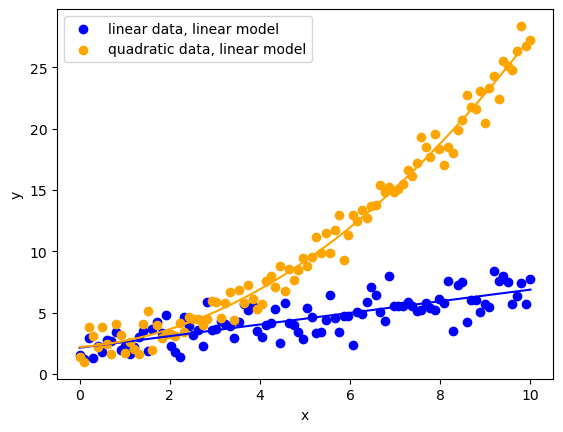

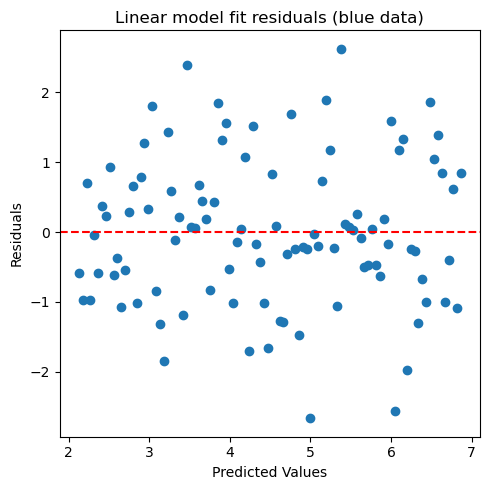

In [27]:
#comparing for linearity (quadratic relation between x and y fitted with  linear model)
plt.scatter(x4,y4_ok, color='blue',label='linear data, linear model' )
plt.plot(x4,y4_pred_ok, color='blue')
plt.scatter(x4,y4,color='orange',label='quadratic data, linear model')
plt.plot(x4,y4_pred, color='orange')
plt.xlabel('x')
plt.ylabel('y')

plt.legend()

fig, axes = plt.subplots(1, 1, figsize=(5, 5))
axes.scatter(y4_pred_ok, residuals4_ok)
axes.axhline(y=0, color='r', linestyle='--')
axes.set_xlabel('Predicted Values')
axes.set_ylabel('Residuals')
axes.set_title('Linear model fit residuals (blue data)')

plt.tight_layout()
plt.show()


### Back to the students data

The same residual checks applied to our dataset.

In [ ]:
# back to our data


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Original data and augmentation
data = {
    'Quizzes': [5.3, 5.5, 5.5, 5.0, 2.5, 3.0, 3.0, 3.1, 3.5, 3.5, 3.7, 4.0, 4.0, 4.0, 4.0, 5.7],
    'Labs': [5.3, 5.9, 5.29, 4.35, 5.5, 5.0, 4.0, 3.1, 4.5, 5.62, 5.0, 3.0, 4.0, 5.75, 4.44, 5.9],
    'Final': [4.818, 5.773, 4.464, 5.069, 4.164, 4.091, 3.727, 3.909, 3.518, 4.897, 5.209, 3.0, 3.091, 5.818, 4.069, 5.77]
}
df = pd.DataFrame(data)

# Augment data
np.random.seed(42)
augmented = []
for i in range(len(df)):
    row = df.iloc[i]
    for _ in range(10):
        noise = np.random.normal(0, 0.2, 3)
        new_row = row + noise
        new_row = new_row.clip(2, 6)
        augmented.append(new_row)

df_aug = pd.DataFrame(augmented, columns=df.columns)

# Fit linear regression
X = df_aug['Labs'].values.reshape(-1, 1)
y = df_aug['Final'].values
X_with_ones = np.column_stack([np.ones(len(X)), X])
theta = np.linalg.inv(X_with_ones.T @ X_with_ones) @ X_with_ones.T @ y

# Calculate predicted values and residuals
y_pred = X_with_ones @ theta
residuals = y - y_pred
standardized_residuals = residuals / np.std(residuals)

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
fig.suptitle('Linear Regression Assumptions Check - Labs vs Final', fontsize=16)

# 1. Linearity Check - Scatter plot with regression line
axes[0,0].scatter(X, y, alpha=0.5)
axes[0,0].plot(X, y_pred, color='red', linewidth=2)
axes[0,0].set_xlabel('Labs Score')
axes[0,0].set_ylabel('Final Score')
axes[0,0].set_title('Linearity Check\nScatter Plot with Regression Line')

# 2. Homoscedasticity - Residuals vs Fitted
axes[0,1].scatter(y_pred, residuals, alpha=0.5)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Homoscedasticity Check\nResiduals vs Fitted Values')

# 3. Normality - QQ Plot
stats.probplot(standardized_residuals, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Normality Check\nQ-Q Plot')

# 4. Residuals Distribution
sns.histplot(standardized_residuals, kde=True, ax=axes[1,1])
axes[1,1].set_xlabel('Standardized Residuals')
axes[1,1].set_title('Normality Check\nResiduals Distribution')

plt.tight_layout()

# Print statistical tests and metrics
print("Linear Regression Assumptions Tests:")
print("-" * 40)

#  Linearity - Correlation test
correlation = np.corrcoef(X.flatten(), y)[0,1]
print(f"1. Linearity:")
print(f"   - Correlation coefficient: {correlation:.4f}")
print(f"   - R-squared: {1 - (np.sum(residuals**2) / np.sum((y - np.mean(y))**2)):.4f}")

#  Homoscedasticity - Correlation between absolute residuals and predicted values
het_corr, het_p = stats.spearmanr(np.abs(residuals), y_pred)
print(f"\n2. Homoscedasticity:")
print(f"   - Spearman correlation of |residuals| vs predicted: {het_corr:.4f}")
print(f"   - P-value: {het_p:.4f}")
print(f"   - Interpretation: {'Possible heteroscedasticity' if het_p < 0.05 else 'Homoscedasticity assumption appears met'}")

#  Normality tests
_, normality_p = stats.normaltest(residuals)
print(f"\n3. Normality:")
print(f"   - Normality test p-value: {normality_p:.4f}")
print(f"   - Skewness: {stats.skew(residuals):.4f}")
print(f"   - Kurtosis: {stats.kurtosis(residuals):.4f}")
print(f"   - Interpretation: {'Non-normal residuals' if normality_p < 0.05 else 'Normal residuals'}")

# § Additional metrics
print(f"\n4. Additional Information:")
print(f"   - Mean of residuals: {np.mean(residuals):.4f}")
print(f"   - Std of residuals: {np.std(residuals):.4f}")
print(f"   - Range of residuals: [{np.min(residuals):.4f}, {np.max(residuals):.4f}]")

plt.show()

For homoscedastisicy (equality of variance in the residuals) one of the best ways to check is by visual inspection of the residuals plot.

In [30]:
x1 = np.linspace(0, 10, 100)
noise1 = np.random.normal(0, 0.1 + 0.3 * x1, 100)
y1 = 2 + 0.5 * x1 + noise1
model1 = np.polyfit(x1, y1, 1)
y1_pred = np.polyval(model1, x1)
residuals1 = y1 - y1_pred

y1_ok = 2 + 0.5 * x1 ++ np.random.normal(0, 1, 100)
model1_ok = np.polyfit(x1, y1_ok, 1)
y1_pred_ok = np.polyval(model1_ok, x1)
residuals1_ok = y1_ok - y1_pred_ok


axes[0,1].scatter(y1_pred, residuals1)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Values')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Heteroscedasticity\n(Fan-shaped pattern)')

Text(0.5, 1.0, 'Heteroscedasticity\n(Fan-shaped pattern)')

Side by side: homoscedastic and heteroscedastic data under the same linear model. The fan shape in the second residual plot is the signature of growing variance.

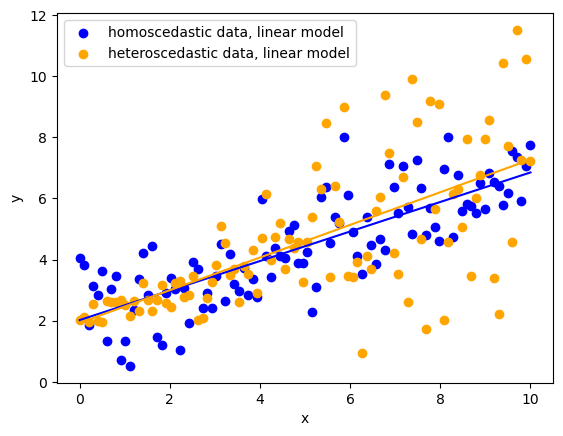

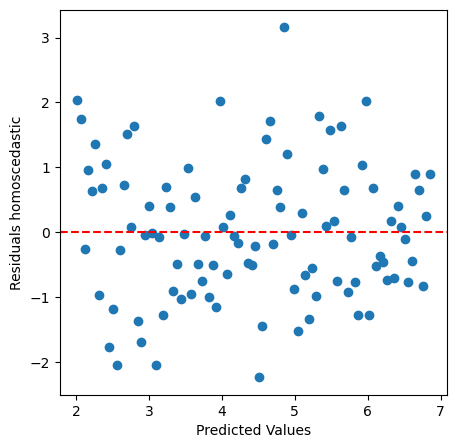

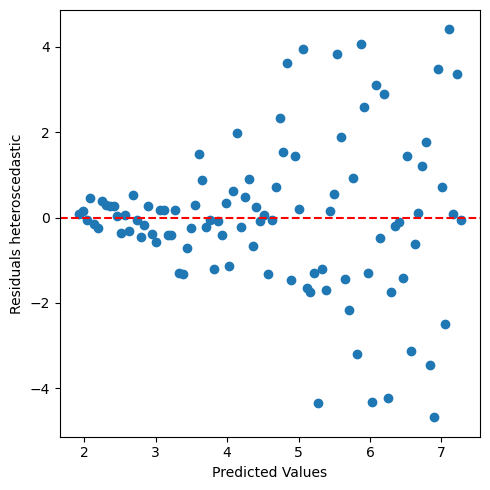

In [31]:
#comparing for homopscedasticity (equality of variance of the residuals over the whole range)
plt.scatter(x1,y1_ok, color='blue',label='homoscedastic data, linear model' )
plt.plot(x1,y1_pred_ok, color='blue')
plt.scatter(x1,y1,color='orange',label='heteroscedastic data, linear model')
plt.plot(x1,y1_pred, color='orange')
plt.xlabel('x')
plt.ylabel('y')

plt.legend()

fig, axes = plt.subplots(1, 1, figsize=(5, 5))
plt.scatter(y1_pred_ok, residuals1_ok, label='homoscedastic residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals homoscedastic')

fig, axes = plt.subplots(1, 1, figsize=(5, 5))

plt.scatter(y1_pred, residuals1,label='heteroscedastic residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
axes.set_ylabel('Residuals heteroscedastic')


plt.tight_layout()
plt.show()

Checking for independence

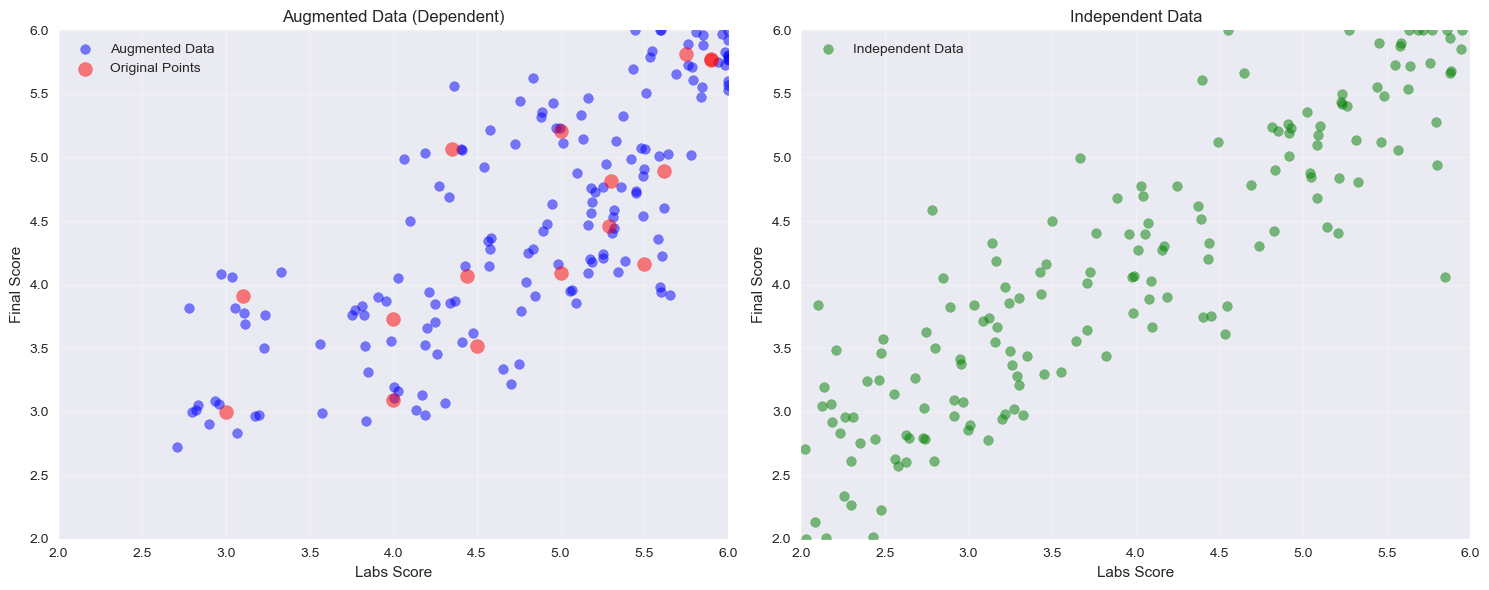


Augmented Data Statistics:
             Labs       Final
count  160.000000  160.000000
mean     4.762389    4.479292
std      0.904538    0.918909
min      2.710383    2.718507
25%      4.189950    3.808585
50%      4.951766    4.432312
75%      5.491895    5.229416
max      6.000000    6.000000

Independent Data Statistics:
             Labs       Final
count  160.000000  160.000000
mean     3.908564    4.126841
std      1.187372    1.088667
min      2.022088    2.000000
25%      2.905913    3.248587
50%      3.856570    4.056825
75%      5.027438    5.069239
max      5.947548    6.000000

Correlation Coefficients:
Augmented Data: 0.7700109814696267
Independent Data: 0.8952450360253382


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Original data
data = {
    'Quizzes': [5.3, 5.5, 5.5, 5.0, 2.5, 3.0, 3.0, 3.1, 3.5, 3.5, 3.7, 4.0, 4.0, 4.0, 4.0, 5.7],
    'Labs': [5.3, 5.9, 5.29, 4.35, 5.5, 5.0, 4.0, 3.1, 4.5, 5.62, 5.0, 3.0, 4.0, 5.75, 4.44, 5.9],
    'Final': [4.818, 5.773, 4.464, 5.069, 4.164, 4.091, 3.727, 3.909, 3.518, 4.897, 5.209, 3.0, 3.091, 5.818, 4.069, 5.77]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Create augmented data
np.random.seed(42)
augmented = []
for i in range(len(df)):
    row = df.iloc[i]
    for _ in range(10):  # Create 10 variations of each record
        noise = np.random.normal(0, 0.2, 3)  # Add Gaussian noise
        new_row = row + noise
        # Ensure values are within boundaries
        new_row = new_row.clip(2, 6)
        augmented.append(new_row)

# Create augmented DataFrame
df_aug = pd.DataFrame(augmented, columns=df.columns)

# Generate independent data
np.random.seed(42)
n_points = len(df_aug)
labs_independent = np.random.uniform(2, 6, n_points)
noise = np.random.normal(0, 0.5, n_points)
final_independent = np.clip(labs_independent * 0.8 + noise + 1, 2, 6)

# Create figure with two subplots
plt.style.use('seaborn-v0_8')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot augmented data
ax1.scatter(df_aug['Labs'], df_aug['Final'], alpha=0.5, c='blue', label='Augmented Data')
ax1.set_title('Augmented Data (Dependent)')
ax1.set_xlabel('Labs Score')
ax1.set_ylabel('Final Score')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2, 6)
ax1.set_ylim(2, 6)

# Plot original points to highlight clusters
ax1.scatter(df['Labs'], df['Final'], c='red', s=100, alpha=0.5, label='Original Points')
ax1.legend()

# Plot independent data
ax2.scatter(labs_independent, final_independent, alpha=0.5, c='green', label='Independent Data')
ax2.set_title('Independent Data')
ax2.set_xlabel('Labs Score')
ax2.set_ylabel('Final Score')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(2, 6)
ax2.set_ylim(2, 6)
ax2.legend()

plt.tight_layout()
plt.show()

# Print some statistics to compare the distributions
print("\nAugmented Data Statistics:")
print(df_aug[['Labs', 'Final']].describe())
print("\nIndependent Data Statistics:")
independent_df = pd.DataFrame({'Labs': labs_independent, 'Final': final_independent})
print(independent_df.describe())

# Calculate and print correlation coefficients
print("\nCorrelation Coefficients:")
print("Augmented Data:", np.corrcoef(df_aug['Labs'], df_aug['Final'])[0,1])
print("Independent Data:", np.corrcoef(labs_independent, final_independent)[0,1])

Available matplotlib styles, for reference.

In [ ]:
plt.style.available

### Independence and the augmentation

Our augmented dataset contains 10 noisy copies of every student, so the residuals of the copies are correlated. Comparing a fit on the 16 originals with a fit on the 160 augmented samples shows what the duplication does to the residual structure: a point to keep in mind whenever augmented data is used for inference.

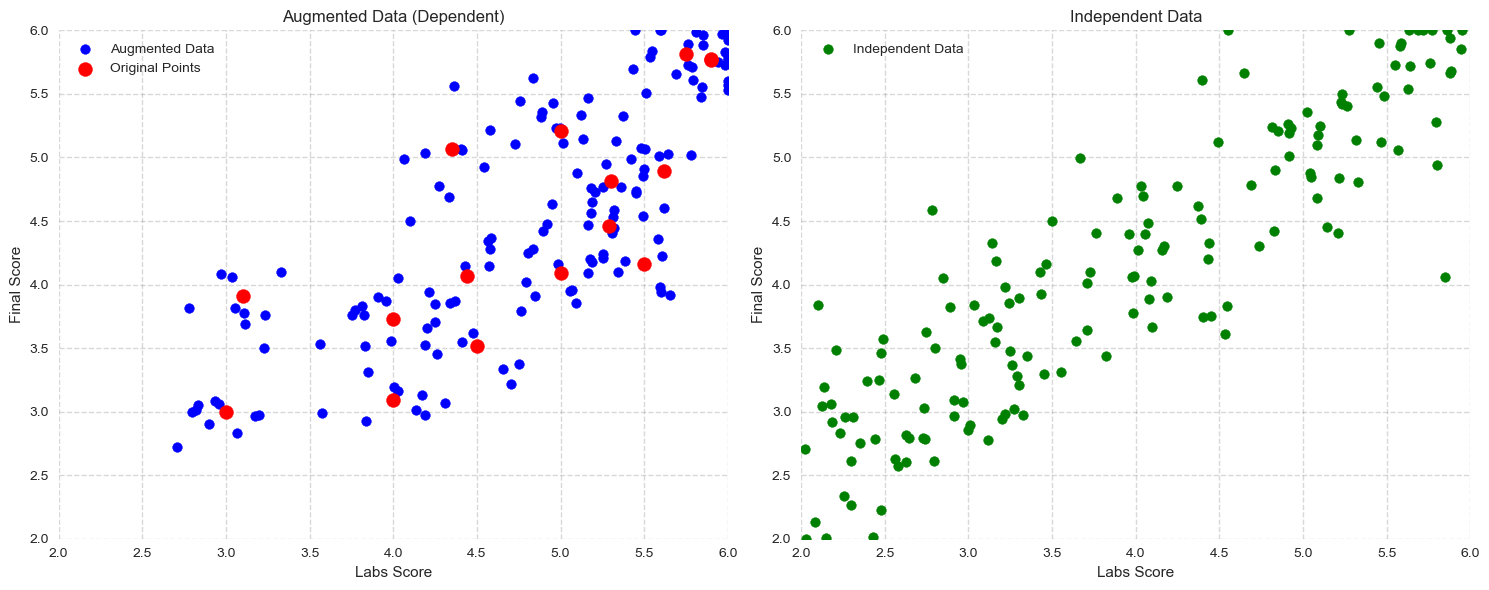

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Original data
data = {
    'Quizzes': [5.3, 5.5, 5.5, 5.0, 2.5, 3.0, 3.0, 3.1, 3.5, 3.5, 3.7, 4.0, 4.0, 4.0, 4.0, 5.7],
    'Labs': [5.3, 5.9, 5.29, 4.35, 5.5, 5.0, 4.0, 3.1, 4.5, 5.62, 5.0, 3.0, 4.0, 5.75, 4.44, 5.9],
    'Final': [4.818, 5.773, 4.464, 5.069, 4.164, 4.091, 3.727, 3.909, 3.518, 4.897, 5.209, 3.0, 3.091, 5.818, 4.069, 5.77]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Create augmented data
np.random.seed(42)
augmented = []
for i in range(len(df)):
    row = df.iloc[i]
    for _ in range(10):
        noise = np.random.normal(0, 0.2, 3)
        new_row = row + noise
        new_row = new_row.clip(2, 6)
        augmented.append(new_row)

df_aug = pd.DataFrame(augmented, columns=df.columns)

# Generate independent data
np.random.seed(42)
n_points = len(df_aug)
labs_independent = np.random.uniform(2, 6, n_points)
noise = np.random.normal(0, 0.5, n_points)
final_independent = np.clip(labs_independent * 0.8 + noise + 1, 2, 6)

# Create figure with white background
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('white')
ax1.set_facecolor('white')
ax2.set_facecolor('white')

# Plot augmented data
ax1.scatter(df_aug['Labs'], df_aug['Final'],  color='blue', label='Augmented Data')
ax1.scatter(df['Labs'], df['Final'], color='red', s=100,  label='Original Points')
ax1.set_title('Augmented Data (Dependent)')
ax1.set_xlabel('Labs Score')
ax1.set_ylabel('Final Score')
ax1.grid(True, alpha=0.3, color='gray', linestyle='--')
ax1.set_xlim(2, 6)
ax1.set_ylim(2, 6)
ax1.legend()

# Plot independent data
ax2.scatter(labs_independent, final_independent,  color='green', label='Independent Data')
ax2.set_title('Independent Data')
ax2.set_xlabel('Labs Score')
ax2.set_ylabel('Final Score')
ax2.grid(True, alpha=0.3, color='gray', linestyle='--')
ax2.set_xlim(2, 6)
ax2.set_ylim(2, 6)
ax2.legend()

plt.tight_layout()
plt.show()


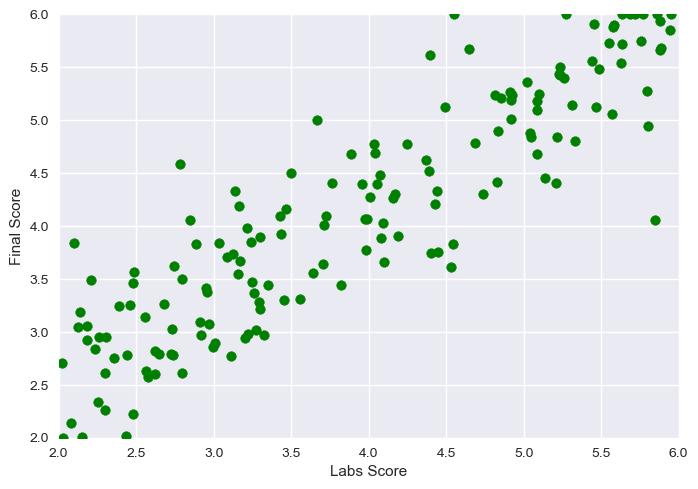

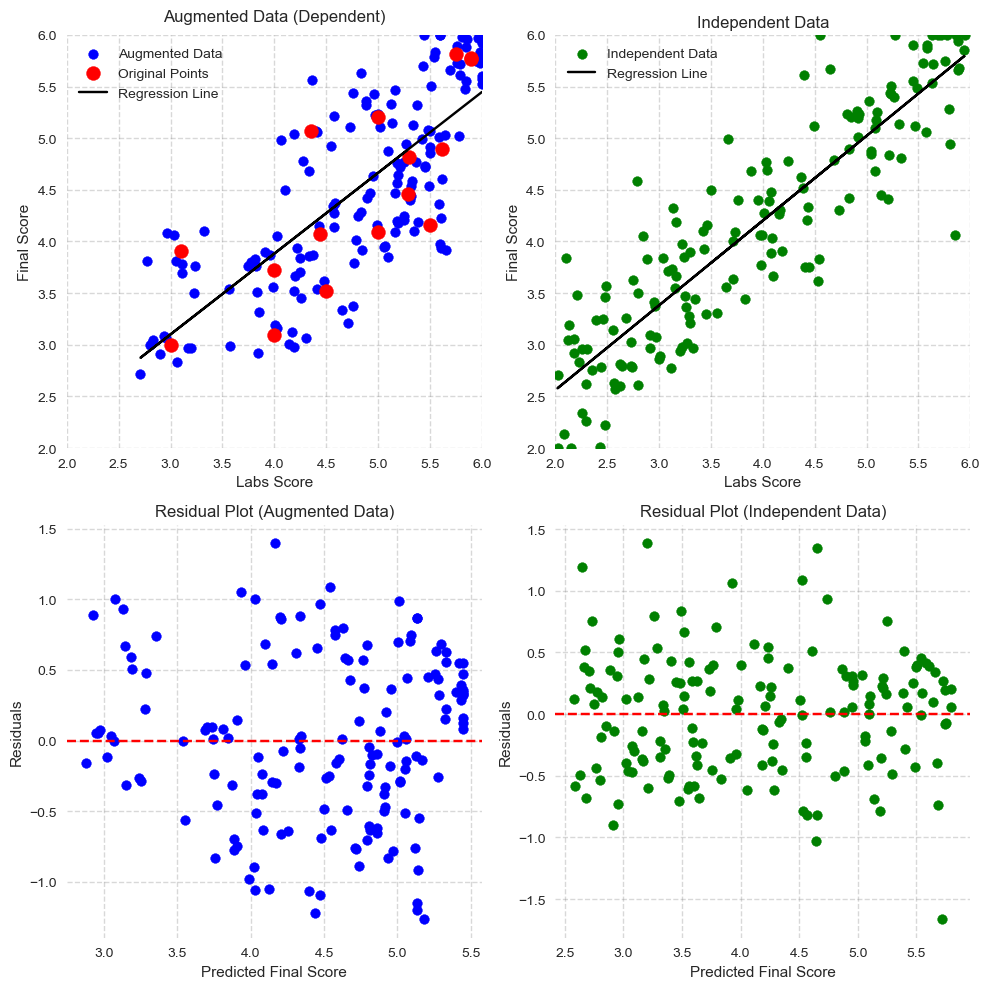


Regression Statistics:
Augmented Data R² score: 0.5929169115838182
Independent Data R² score: 0.8014636745280083


In [35]:
from sklearn.linear_model import LinearRegression
# Fit linear regression and get residuals for augmented data
reg_aug = LinearRegression()
X_aug = df_aug['Labs'].values.reshape(-1, 1)
y_aug = df_aug['Final'].values
reg_aug.fit(X_aug, y_aug)
y_pred_aug = reg_aug.predict(X_aug)
residuals_aug = y_aug - y_pred_aug

# Fit linear regression and get residuals for independent data
reg_ind = LinearRegression()
X_ind = labs_independent.reshape(-1, 1)
reg_ind.fit(X_ind, final_independent)
y_pred_ind = reg_ind.predict(X_ind)
residuals_ind = final_independent - y_pred_ind


#plot raw data that are artificially created but nicely linear

plt.figure()
plt.scatter(labs_independent, final_independent, alpha=1, color='green')
plt.xlabel('Labs Score')
plt.ylabel('Final Score')
plt.xlim(2, 6)
plt.ylim(2, 6)

plt.show()

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10, 10))
fig.patch.set_facecolor('white')
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_facecolor('white')

#  augmented data and regression line
ax1.scatter(df_aug['Labs'], df_aug['Final'], alpha=1, color='blue', label='Augmented Data')
ax1.scatter(df['Labs'], df['Final'], color='red', s=100, alpha=1, label='Original Points')
ax1.plot(X_aug, y_pred_aug, color='black', linestyle='-', label='Regression Line')
ax1.set_title('Augmented Data (Dependent)', pad=10)
ax1.set_xlabel('Labs Score')
ax1.set_ylabel('Final Score')
ax1.grid(True, alpha=0.3, color='gray', linestyle='--')
ax1.set_xlim(2, 6)
ax1.set_ylim(2, 6)
ax1.legend()

#  independent data and regression line
ax2.scatter(labs_independent, final_independent, alpha=1, color='green', label='Independent Data')
ax2.plot(X_ind, y_pred_ind, color='black', linestyle='-', label='Regression Line')
ax2.set_title('Independent Data')
ax2.set_xlabel('Labs Score')
ax2.set_ylabel('Final Score')
ax2.grid(True, alpha=0.3, color='gray', linestyle='--')
ax2.set_xlim(2, 6)
ax2.set_ylim(2, 6)
ax2.legend()

#  independent data and no regression line
#ax3.scatter(labs_independent, final_independent, alpha=1, color='green', label='Final')
#ax3.set_title('Independent Data')
#ax3.set_xlabel('Labs Score')
#ax3.set_ylabel('Final Score')
#ax3.grid(True, alpha=0.3, color='gray', linestyle='--')
#ax3.set_xlim(2, 6)
#ax3.set_ylim(2, 6)
#ax3.legend()

#  residuals for augmented data
ax3.scatter(y_pred_aug, residuals_aug, alpha=1, color='blue')
ax3.axhline(y=0, color='red', linestyle='--')
ax3.set_title('Residual Plot (Augmented Data)')
ax3.set_xlabel('Predicted Final Score')
ax3.set_ylabel('Residuals')
ax3.grid(True, alpha=0.3, color='gray', linestyle='--')

# residuals for independent data
ax4.scatter(y_pred_ind, residuals_ind, alpha=1, color='green')
ax4.axhline(y=0, color='red', linestyle='--')
ax4.set_title('Residual Plot (Independent Data)')
ax4.set_xlabel('Predicted Final Score')
ax4.set_ylabel('Residuals')
ax4.grid(True, alpha=0.3, color='gray', linestyle='--')

plt.tight_layout()
plt.show()

# Print regression statistics
print("\nRegression Statistics:")
print("Augmented Data R² score:", reg_aug.score(X_aug, y_aug))
print("Independent Data R² score:", reg_ind.score(X_ind, final_independent))

Regression task with clusters

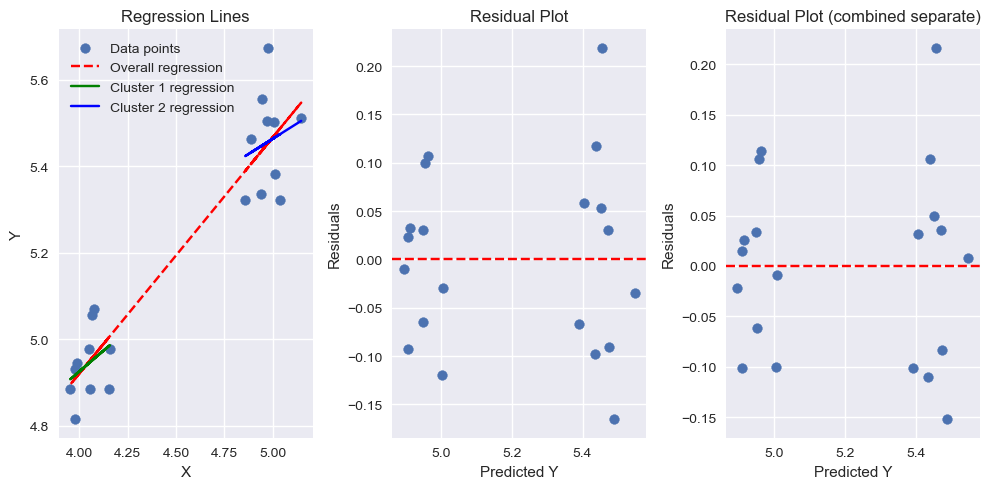

Sum of squared residuals (overall): 0.171442
Sum of squared residuals (within clusters): 0.165919
Ratio (overall/within): 1.03


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Generates two clusters of points
np.random.seed(42)
# Cluster 1
x1 = np.random.normal(4, 0.1, 10)
y1 = 3 + 0.5*x1 + np.random.normal(0, 0.1, 10)

# Cluster 2
x2 = np.random.normal(5, 0.1, 10)
y2 = 3 + 0.5*x2 + np.random.normal(0, 0.1, 10)

# Combines points
X = np.concatenate([x1, x2]).reshape(-1, 1)
y = np.concatenate([y1, y2])

# Overall regression
reg_all = LinearRegression()
reg_all.fit(X, y)
y_pred_all = reg_all.predict(X)
residuals_all = y - y_pred_all

# Separates regressions for each cluster
reg1 = LinearRegression()
reg1.fit(x1.reshape(-1, 1), y1)
y_pred1 = reg1.predict(x1.reshape(-1, 1))
residuals1 = y1 - y_pred1

reg2 = LinearRegression()
reg2.fit(x2.reshape(-1, 1), y2)
y_pred2 = reg2.predict(x2.reshape(-1, 1))
residuals2 = y2 - y_pred2

# Calculates sum of squared residuals
ssr_all = np.sum(residuals_all**2)
ssr_clusters = np.sum(residuals1**2) + np.sum(residuals2**2)


plt.figure(figsize=(10, 5))
plt.subplot(131)
plt.scatter(X, y, alpha=1, label='Data points')
plt.plot(X, y_pred_all, 'r--', label='Overall regression')
plt.plot(x1, y_pred1, 'g-', label='Cluster 1 regression')
plt.plot(x2, y_pred2, 'b-', label='Cluster 2 regression')
plt.title('Regression Lines')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()

plt.subplot(132)
plt.scatter(y_pred_all, residuals_all, alpha=1)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Y')
plt.ylabel('Residuals')

plt.subplot(133)
plt.scatter(y_pred_all, [residuals1, residuals2], alpha=1)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residual Plot (combined separate)')
plt.xlabel('Predicted Y')
plt.ylabel('Residuals')


plt.tight_layout()
plt.show()

print(f"Sum of squared residuals (overall): {ssr_all:.6f}")
print(f"Sum of squared residuals (within clusters): {ssr_clusters:.6f}")
print(f"Ratio (overall/within): {ssr_all/ssr_clusters:.2f}")

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats


# the multivariate fit from part 1, rebuilt here so this cell does not depend on earlier ones
X_mv = df_aug[['Quizzes', 'Labs']].values
y_mv = df_aug['Final'].values
X_with_ones = np.column_stack([np.ones(len(X_mv)), X_mv])
theta_opt = np.linalg.inv(X_with_ones.T @ X_with_ones) @ X_with_ones.T @ y_mv

# Calculate predicted values and residuals
y = y_mv
y_pred = X_with_ones @ theta_opt
residuals = y - y_pred
standardized_residuals = residuals / np.std(residuals)

# Create a figure for diagnostics
plt.figure(figsize=(20, 15))

# 1. Residuals vs Fitted Values Plot
plt.subplot(2, 2, 1)
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values\n(Check for Linearity and Homoscedasticity)')

# 2. Q-Q Plot for Normality
plt.subplot(2, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Normal Q-Q Plot\n(Check for Normality of Residuals)')

# 3. Scale-Location Plot
plt.subplot(2, 2, 3)
plt.scatter(y_pred, np.abs(standardized_residuals))
plt.xlabel('Fitted Values')
plt.ylabel('|Standardized Residuals|^1/2')
plt.title('Scale-Location Plot\n(Check for Homoscedasticity)')

# 4. Correlation Matrix Heatmap
plt.subplot(2, 2, 4)
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix\n(Check for Multicollinearity)')

plt.tight_layout()

# Statistical Tests
print("\nDiagnostic Tests:")
print("-----------------")

# 1. Normality Test (Shapiro-Wilk)
_, p_value_normality = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test for Normality:")
print(f"p-value: {p_value_normality:.4f}")
print(f"Interpretation: {'Residuals appear normal' if p_value_normality > 0.05 else 'Residuals may not be normal'}")

# 2. Manual Heteroscedasticity Test (Spearman correlation between absolute residuals and predicted values)
correlation, p_value_hetero = stats.spearmanr(np.abs(residuals), y_pred)
print(f"\nHeteroscedasticity Test (Spearman correlation):")
print(f"Correlation: {correlation:.4f}")
print(f"p-value: {p_value_hetero:.4f}")
print(f"Interpretation: {'Homoscedasticity assumption holds' if p_value_hetero > 0.05 else 'Heteroscedasticity may be present'}")


# 4. Model Fit Statistics
n = len(y)
p = X.shape[1]
r_squared = 1 - (np.sum(residuals**2) / np.sum((y - np.mean(y))**2))
adj_r_squared = 1 - ((1 - r_squared) * (n - 1) / (n - p - 1))

print("\nModel Fit Statistics:")
print(f"R-squared: {r_squared:.4f}")
print(f"Adjusted R-squared: {adj_r_squared:.4f}")

# 5. Additional residual statistics
print("\nResidual Statistics:")
print(f"Mean of residuals: {np.mean(residuals):.4f}")
print(f"Standard deviation of residuals: {np.std(residuals):.4f}")


plt.show()

**Checking for correlated features (multicollinearity)**

Suppose two features say almost the same thing, for example a lab score recorded twice on different scales. The model then cannot tell which of the two deserves the credit: it can add a large weight to one and subtract it from the other and still predict equally well. Many different coefficient values fit the data about equally, so the ones we get are unstable, and reading them as "the effect of this feature" becomes meaningless. The predictions stay fine; only their interpretation breaks.

In the covariance language of the lecture: $\boldsymbol{\Sigma}_{xx}$ is close to singular, so $\boldsymbol{\Sigma}_{xx}^{-1}$ blows up.

Three ways to check, from mildest to sharpest: the correlation between features, the condition number of the standardized feature matrix, and the variance inflation factor (VIF).

In [ ]:
# --- how related are the two features? three views of the same thing ---
features = ['Quizzes', 'Labs']
Xf = df_aug[features].values

# 1) correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(df_aug.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation matrix (augmented data)')
plt.show()

r, p_value = stats.pearsonr(df_aug['Quizzes'], df_aug['Labs'])
print(f"correlation(Quizzes, Labs) = {r:.2f}   (p = {p_value:.4f})")

# 2) condition number of the standardized feature matrix
#    standardize per column: subtract each column's mean, divide by its std
Xs = (Xf - Xf.mean(axis=0)) / Xf.std(axis=0)
eigenvals = np.linalg.eigvalsh(Xs.T @ Xs)
condition_number = np.sqrt(eigenvals.max() / eigenvals.min())
print(f"condition number           = {condition_number:.2f}   (>30 signals strong multicollinearity)")

# 3) variance inflation factor: 1 / (1 - R^2) of each feature regressed on the others
from statsmodels.stats.outliers_influence import variance_inflation_factor
for j, name in enumerate(features):
    print(f"VIF({name:8s})           = {variance_inflation_factor(Xf, j):.2f}   (>5 concern, >10 serious)")

print("\nHere all three agree: the features are only mildly related, so the model is well behaved.")

**What the VIF measures.** For feature $j$, regress that feature on all the *other* features and take the $R^2$ of that regression:

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

It answers: how much of this feature do the other features already explain?

| $R_j^2$ | VIF | reading |
|---|---|---|
| 0 | 1 | shares nothing with the others |
| 0.5 | 2 | half of it is predictable from the others |
| 0.9 | 10 | almost redundant |
| 0.99 | 100 | essentially a duplicate |

The name comes from the effect on the coefficient: the variance of $\hat{\theta}_j$ is multiplied by exactly this factor compared with uncorrelated features, so a VIF of 100 makes the standard error 10 times larger. Rules of thumb: above 5 is a concern, above 10 is serious.

The cell below computes it both ways, from the definition and with `statsmodels`, so the formula is not a black box.

In [ ]:
# the VIF from its definition: regress each feature on the others
def vif_from_definition(X, j):
    y_j = X[:, j]                                  # the feature being explained
    others = np.delete(X, j, axis=1)               # all the other features
    others = np.column_stack([np.ones(len(others)), others])   # with an intercept
    coef, *_ = np.linalg.lstsq(others, y_j, rcond=None)
    residuals = y_j - others @ coef
    r2 = 1 - (residuals ** 2).sum() / ((y_j - y_j.mean()) ** 2).sum()
    return r2, 1 / (1 - r2)

print(f"{'feature':10s} {'R^2 on the others':>18s} {'VIF (definition)':>18s} {'VIF (statsmodels)':>19s}")
for j, name in enumerate(features):
    r2, v = vif_from_definition(Xf, j)
    print(f"{name:10s} {r2:18.3f} {v:18.2f} {variance_inflation_factor(Xf, j):19.2f}")

**Reading these numbers.** Quizzes and Labs correlate at 0.37, the condition number is 1.48 and both VIFs are 1.16, so the two features are only mildly related: each carries information the other does not. The correlation is still large enough to change the coefficients. The Labs slope is 0.78 on its own and 0.70 once Quizzes is in the model, because the multivariate coefficient reports what Labs adds *beyond* Quizzes.

**What real multicollinearity looks like.** The cell below adds a feature that is almost a copy of Labs. Watch the VIF explode and the two coefficients become unstable, while the predictions barely change.

In [ ]:
# a near-duplicate feature: Labs measured twice, with a little noise
rng = np.random.default_rng(0)
labs_copy = df_aug['Labs'].values + rng.normal(0, 0.05, len(df_aug))
X_dup = np.column_stack([df_aug['Quizzes'].values, df_aug['Labs'].values, labs_copy])
y_dup = df_aug['Final'].values

print("VIF with the near-duplicate feature")
for j, name in enumerate(['Quizzes', 'Labs', 'Labs copy']):
    print(f"  {name}: {variance_inflation_factor(X_dup, j):9.1f}")

# coefficients on two halves of the data: stable or not?
for name, idx in [('first half', slice(0, len(X_dup) // 2)), ('second half', slice(len(X_dup) // 2, None))]:
    Xd = np.column_stack([np.ones(len(X_dup[idx])), X_dup[idx]])
    theta = np.linalg.lstsq(Xd, y_dup[idx], rcond=None)[0]
    print(f"{name:12s} coefficients: Quizzes {theta[1]:6.2f}, Labs {theta[2]:7.2f}, Labs copy {theta[3]:7.2f}")

**What just happened.** The copy of Labs carries no new information, so the two Labs coefficients can trade off against each other freely: on one half of the data the model puts the weight on Labs, on the other half on the copy, and one coefficient even changes sign. The VIF of 367 says each of them is almost fully explained by the other. Predictions and $R^2$ barely move, which is the signature of redundancy: the model is fine, the individual coefficients are not.

**What to do about it:** drop one of the redundant features, combine them (for example their average), or keep both and shrink the coefficients with a penalty, which is what ridge regression does.